In [1]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.model_selection import train_test_split
import matplotlib as plt

In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [4]:
trains = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
X_, y_= torch.Tensor(trains.drop("label",axis=1).values)/255, torch.LongTensor(trains.label.values)
X = torch.Tensor(pd.read_csv("/kaggle/input/digit-recognizer/test.csv").values)/255
X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=0.15, random_state=42, shuffle=True)

In [5]:
X_train = X_train.reshape(27988800//(28*28), 1, 28, 28)
X_test = X_test.reshape(6300, 1, 28, 28)

X = X.reshape(21952000//(28*28), 1, 28, 28)

tensor(3) tensor(6) tensor(2) tensor(3) tensor(8) tensor(1) tensor(6) tensor(7) tensor(0) tensor(2) 

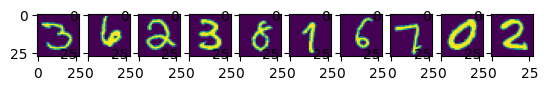

In [6]:
plt.figure.Figure(figsize=(20,2))
for i in range(10):
    plt.pyplot.subplot(1, 10, i+1)
    plt.pyplot.imshow(X_train[i][0])
    print(y_train[i], end=' ')

In [33]:
from torch import nn

class LeNet5V1(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),   # 28*28->32*32-->28*28
            nn.BatchNorm2d(num_features = 6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14*14
            #nn.Dropout(p=0.2),
            
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),  # 10*10
            nn.BatchNorm2d(num_features = 16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 5*5
            #nn.Dropout(p=0.2),
            
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16*5*5, out_features=120),
            nn.ReLU(),
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=10),
        )

        
    def forward(self, x):
        return self.classifier(self.feature(x))

In [35]:
model = LeNet5V1()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [29]:
def train(net, X_train, y_train, X_test, y_test):
    net = net.to(device)
    loss = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(net.parameters(), lr=1.0e-2)

    batch_size = 1000

    test_accuracy_history = []
    test_loss_history = []

    X_test = X_test.to(device)
    y_test = y_test.to(device)
    for epoch in range(100):
        order = np.random.permutation(len(X_train))
        for start_index in range(0, len(X_train), batch_size):
            optimizer.zero_grad()
            net.train()

            batch_indexes = order[start_index:start_index+batch_size]

            X_batch = X_train[batch_indexes].to(device)
            y_batch = y_train[batch_indexes].to(device)

            preds = net.forward(X_batch)

            loss_value = loss(preds, y_batch)
            loss_value.backward()

            optimizer.step()
            
            X_batch

        net.eval()
        test_preds = net.forward(X_test)
        test_loss_history.append(loss(test_preds, y_test).data.cpu())

        accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
        test_accuracy_history.append(accuracy)

        print(accuracy)
    del net
    return test_accuracy_history, test_loss_history

In [36]:
accuracy, loss = train(model, X_train, y_train, X_test, y_test)

tensor(0.9424)
tensor(0.9741)
tensor(0.9725)
tensor(0.9808)
tensor(0.9776)
tensor(0.9816)
tensor(0.9770)
tensor(0.9849)
tensor(0.9856)
tensor(0.9843)
tensor(0.9832)
tensor(0.9860)
tensor(0.9876)
tensor(0.9857)
tensor(0.9846)
tensor(0.9846)
tensor(0.9852)
tensor(0.9879)
tensor(0.9863)
tensor(0.9870)
tensor(0.9879)
tensor(0.9829)
tensor(0.9868)
tensor(0.9848)
tensor(0.9870)
tensor(0.9881)
tensor(0.9881)
tensor(0.9876)
tensor(0.9890)
tensor(0.9892)
tensor(0.9881)
tensor(0.9902)
tensor(0.9905)
tensor(0.9905)
tensor(0.9903)
tensor(0.9905)
tensor(0.9910)
tensor(0.9908)
tensor(0.9905)
tensor(0.9910)
tensor(0.9910)
tensor(0.9906)
tensor(0.9908)
tensor(0.9910)
tensor(0.9908)
tensor(0.9910)
tensor(0.9908)
tensor(0.9910)
tensor(0.9910)
tensor(0.9908)
tensor(0.9908)
tensor(0.9910)
tensor(0.9906)
tensor(0.9908)
tensor(0.9908)
tensor(0.9906)
tensor(0.9908)
tensor(0.9908)
tensor(0.9906)
tensor(0.9906)
tensor(0.9906)
tensor(0.9908)
tensor(0.9908)
tensor(0.9908)
tensor(0.9906)
tensor(0.9906)
tensor(0.9

Text(0.5, 1.0, 'Точность на тестовой выборке')

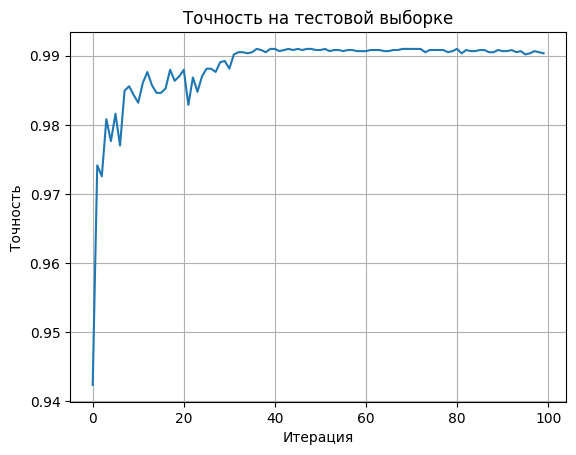

In [37]:
plt.pyplot.plot(accuracy)
plt.pyplot.grid(True)
plt.pyplot.ylabel("Точность")
plt.pyplot.xlabel("Итерация")
plt.pyplot.title("Точность на тестовой выборке")

Text(0.5, 1.0, 'Значения функции потерь на тестовой выборке')

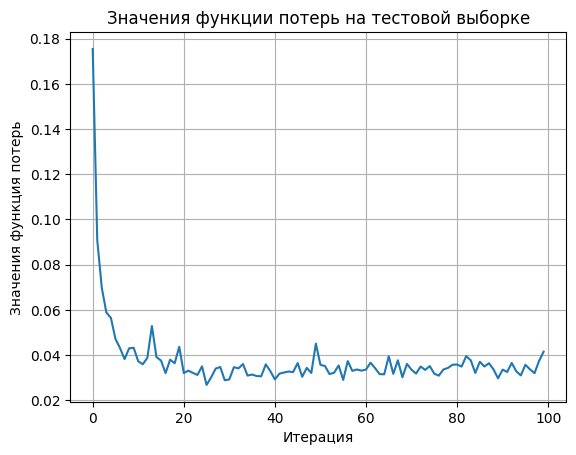

In [26]:
plt.pyplot.plot(loss)
plt.pyplot.grid(True)
plt.pyplot.ylabel("Значения функция потерь")
plt.pyplot.xlabel("Итерация")
plt.pyplot.title("Значения функции потерь на тестовой выборке")

In [13]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X = X.to(device)
pred = model.forward(X).argmax(dim=1)

In [14]:
pred

tensor([2, 0, 9,  ..., 3, 9, 2], device='cuda:0')

In [15]:
pred = (pred.to('cpu')).detach().numpy()

In [16]:
pred

array([2, 0, 9, ..., 3, 9, 2])

In [17]:
submission = pd.read_csv("/kaggle/input/digit-recognizer/sample_submission.csv")
submission["Label"] = pred
submission = submission.to_csv("submission.csv",index=False)

In [18]:
submission